#### Step 2: ML-Focused Exploratory Data Analysis (Gold Layer)

This notebook analyzes the baseline Gold Master(version 1) (which already includes naive baseline features generated from DuckDB). It determines necessary ML transformations such as target skewness correction, collinearity resolution, and identifies what advanced temporal engineering is still needed to fill gaps.


### **EDA Insights & Feature Strategy**

**Distribution & Skewness** * **Sales & Promotions:** Both our target (`weekly_sales`) and our promotional features (`markdowns`) are heavily right-skewed. Most of the time, markdowns sit exactly at zero. But during promotions, they spike drastically. We will apply a `log1p` transformation to these columns. This mathematically compresses those massive holiday spikes into a more manageable range so the model can process them without losing the signal.
* **CPI (Consumer Price Index):** The data shows two distinct peaks with a gap in the middle. This means our dataset either captures a sudden historical jump in inflation, or our stores operate in two completely different regional economies.
* **Store Size:** This feature is clustered rather than a smooth gradient, meaning our stores likely follow specific architectural blueprints (e.g., neighborhood market vs. supercenter). Because treating this as a continuous number might confuse the model, we should group these into a new categorical feature like Small, Medium, and Large.

**Correlation**
* **The Heavy Hitters:** Our engineered lag features drive the model. `sales_last_year` has a 0.98 correlation with the target, and the 4-week rolling average sits at 0.96. This confirms our intuition: the best predictor of this week's sales is what happened recently, or what happened this exact week last year.
* **Secondary Drivers:** Store size (0.24) and markdowns show moderate positive correlations.
* **The Noise:** Macroeconomic factors like CPI, unemployment, and temperature show almost zero direct correlation with weekly sales.
* **Addressing Multicollinearity:** `sales_last_year` and the 4-week average are highly correlated with each other. A standard linear regression would struggle with this, but tree-based models like XGBoost handle it well, especially once we properly shift our rolling averages.

**Handling Missing Values**
* We have a large number of nulls in our engineered features (e.g., 160,000 missing values for `sales_last_year`).
* This is expected. Because our raw data starts in 2010, we simply don't have 2009 data to look back on to calculate the lag.
* **The Fix:** We will treat 2010 as a "warm-up" period and drop those rows. It hurts to lose data, but the trade-off is worth it to unlock `sales_last_year` and our rolling averages, which are our most powerful predictive tools.

**Data Leakage Check**
* Seeing a 0.96 correlation on a rolling average usually sets off alarm bells for data leakage (accidentally including the answer in the feature).
* We verified the SQL logic: the window function strictly uses `ROWS BETWEEN 4 PRECEDING AND 1 PRECEDING`. The current week's sales are mathematically locked out, confirming this high correlation is genuine momentum, not a leak.

**Handling Outliers**
* **Sales & Markdowns (The "Keepers"):** On a box plot, these look like they are entirely made of extreme outliers. Standard statistical practice says to drop outliers, but in retail, those spikes are Black Friday and Christmas. If we drop them, the model fails in December. We keep them all and let the `log1p` transformation do its job.
* **Environment & Time:** Features like temperature, fuel price, and month have clean distributions with virtually no outliers. They are ready for modeling as-is.
* **Unemployment:** There are a few mild outliers here, likely representing specific local economic dips. Because tree-based models are highly robust to mild outliers, we can safely leave these untouched without warping the model's logic.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config

In [ ]:
# Read the master sales parquet
df = pd.read_parquet(config.GOLD_MASTER_PATH)
df.head()

,store,dept,date,weekly_sales,isholiday,store_type,store_size,temperature,fuel_price,cpi,...,markdown2,markdown3,markdown4,markdown5,total_markdown,month,week_of_year,rolling_4_wk_sales_avg,sales_last_year,cpi_lag_3_month
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,211.096359,...,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
1,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,211.096359,...,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
2,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,211.096359,...,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
3,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,211.096359,...,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,NaN
4,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,211.096359,...,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   store                   421570 non-null  int32  
 1   dept                    421570 non-null  int32  
 2   date                    421570 non-null  object 
 3   weekly_sales            421570 non-null  float64
 4   isholiday               421570 non-null  bool   
 5   store_type              421570 non-null  object 
 6   store_size              421570 non-null  int32  
 7   temperature             421570 non-null  float64
 8   fuel_price              421570 non-null  float64
 9   cpi                     421570 non-null  float32
 10  unemployment            421570 non-null  float32
 11  markdown1               421570 non-null  float32
 12  markdown2               421570 non-null  float32
 13  markdown3               421570 non-null  float32
 14  markdown4           

In [ ]:
df.isnull().sum()

store                          0
dept                           0
date                           0
weekly_sales                   0
isholiday                      0
store_type                     0
store_size                     0
temperature                    0
fuel_price                     0
cpi                            0
unemployment                   0
markdown1                      0
markdown2                      0
markdown3                      0
markdown4                      0
markdown5                      0
total_markdown                 0
month                          0
week_of_year                   0
rolling_4_wk_sales_avg      3331
sales_last_year           160487
cpi_lag_3_month              540
dtype: int64

#### 1. Target Distribution (Skewness Check)
If the target (`Weekly_Sales`) is heavily skewed, we may need a log-level transformation (`np.log1p`) inside our ML pipeline.

In [ ]:
numerical_cols = ['weekly_sales', 'store_size', 'sales_last_year', 'rolling_4_wk_sales_avg', 'markdown1','markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
 'temperature', 'fuel_price', 'cpi', 'unemployment', 'month', 'week_of_year', 'cpi_lag_3_month' ]

df[numerical_cols].skew()

weekly_sales               3.262060
store_size                -0.325850
sales_last_year            3.209528
rolling_4_wk_sales_avg     2.814568
markdown1                  4.731304
markdown2                 10.646018
markdown3                 14.922342
markdown4                  8.077667
markdown5                  9.964520
total_markdown             3.890874
temperature               -0.321404
fuel_price                -0.104901
cpi                        0.085219
unemployment               1.183743
month                      0.040786
week_of_year               0.052659
cpi_lag_3_month            0.085210
dtype: float64

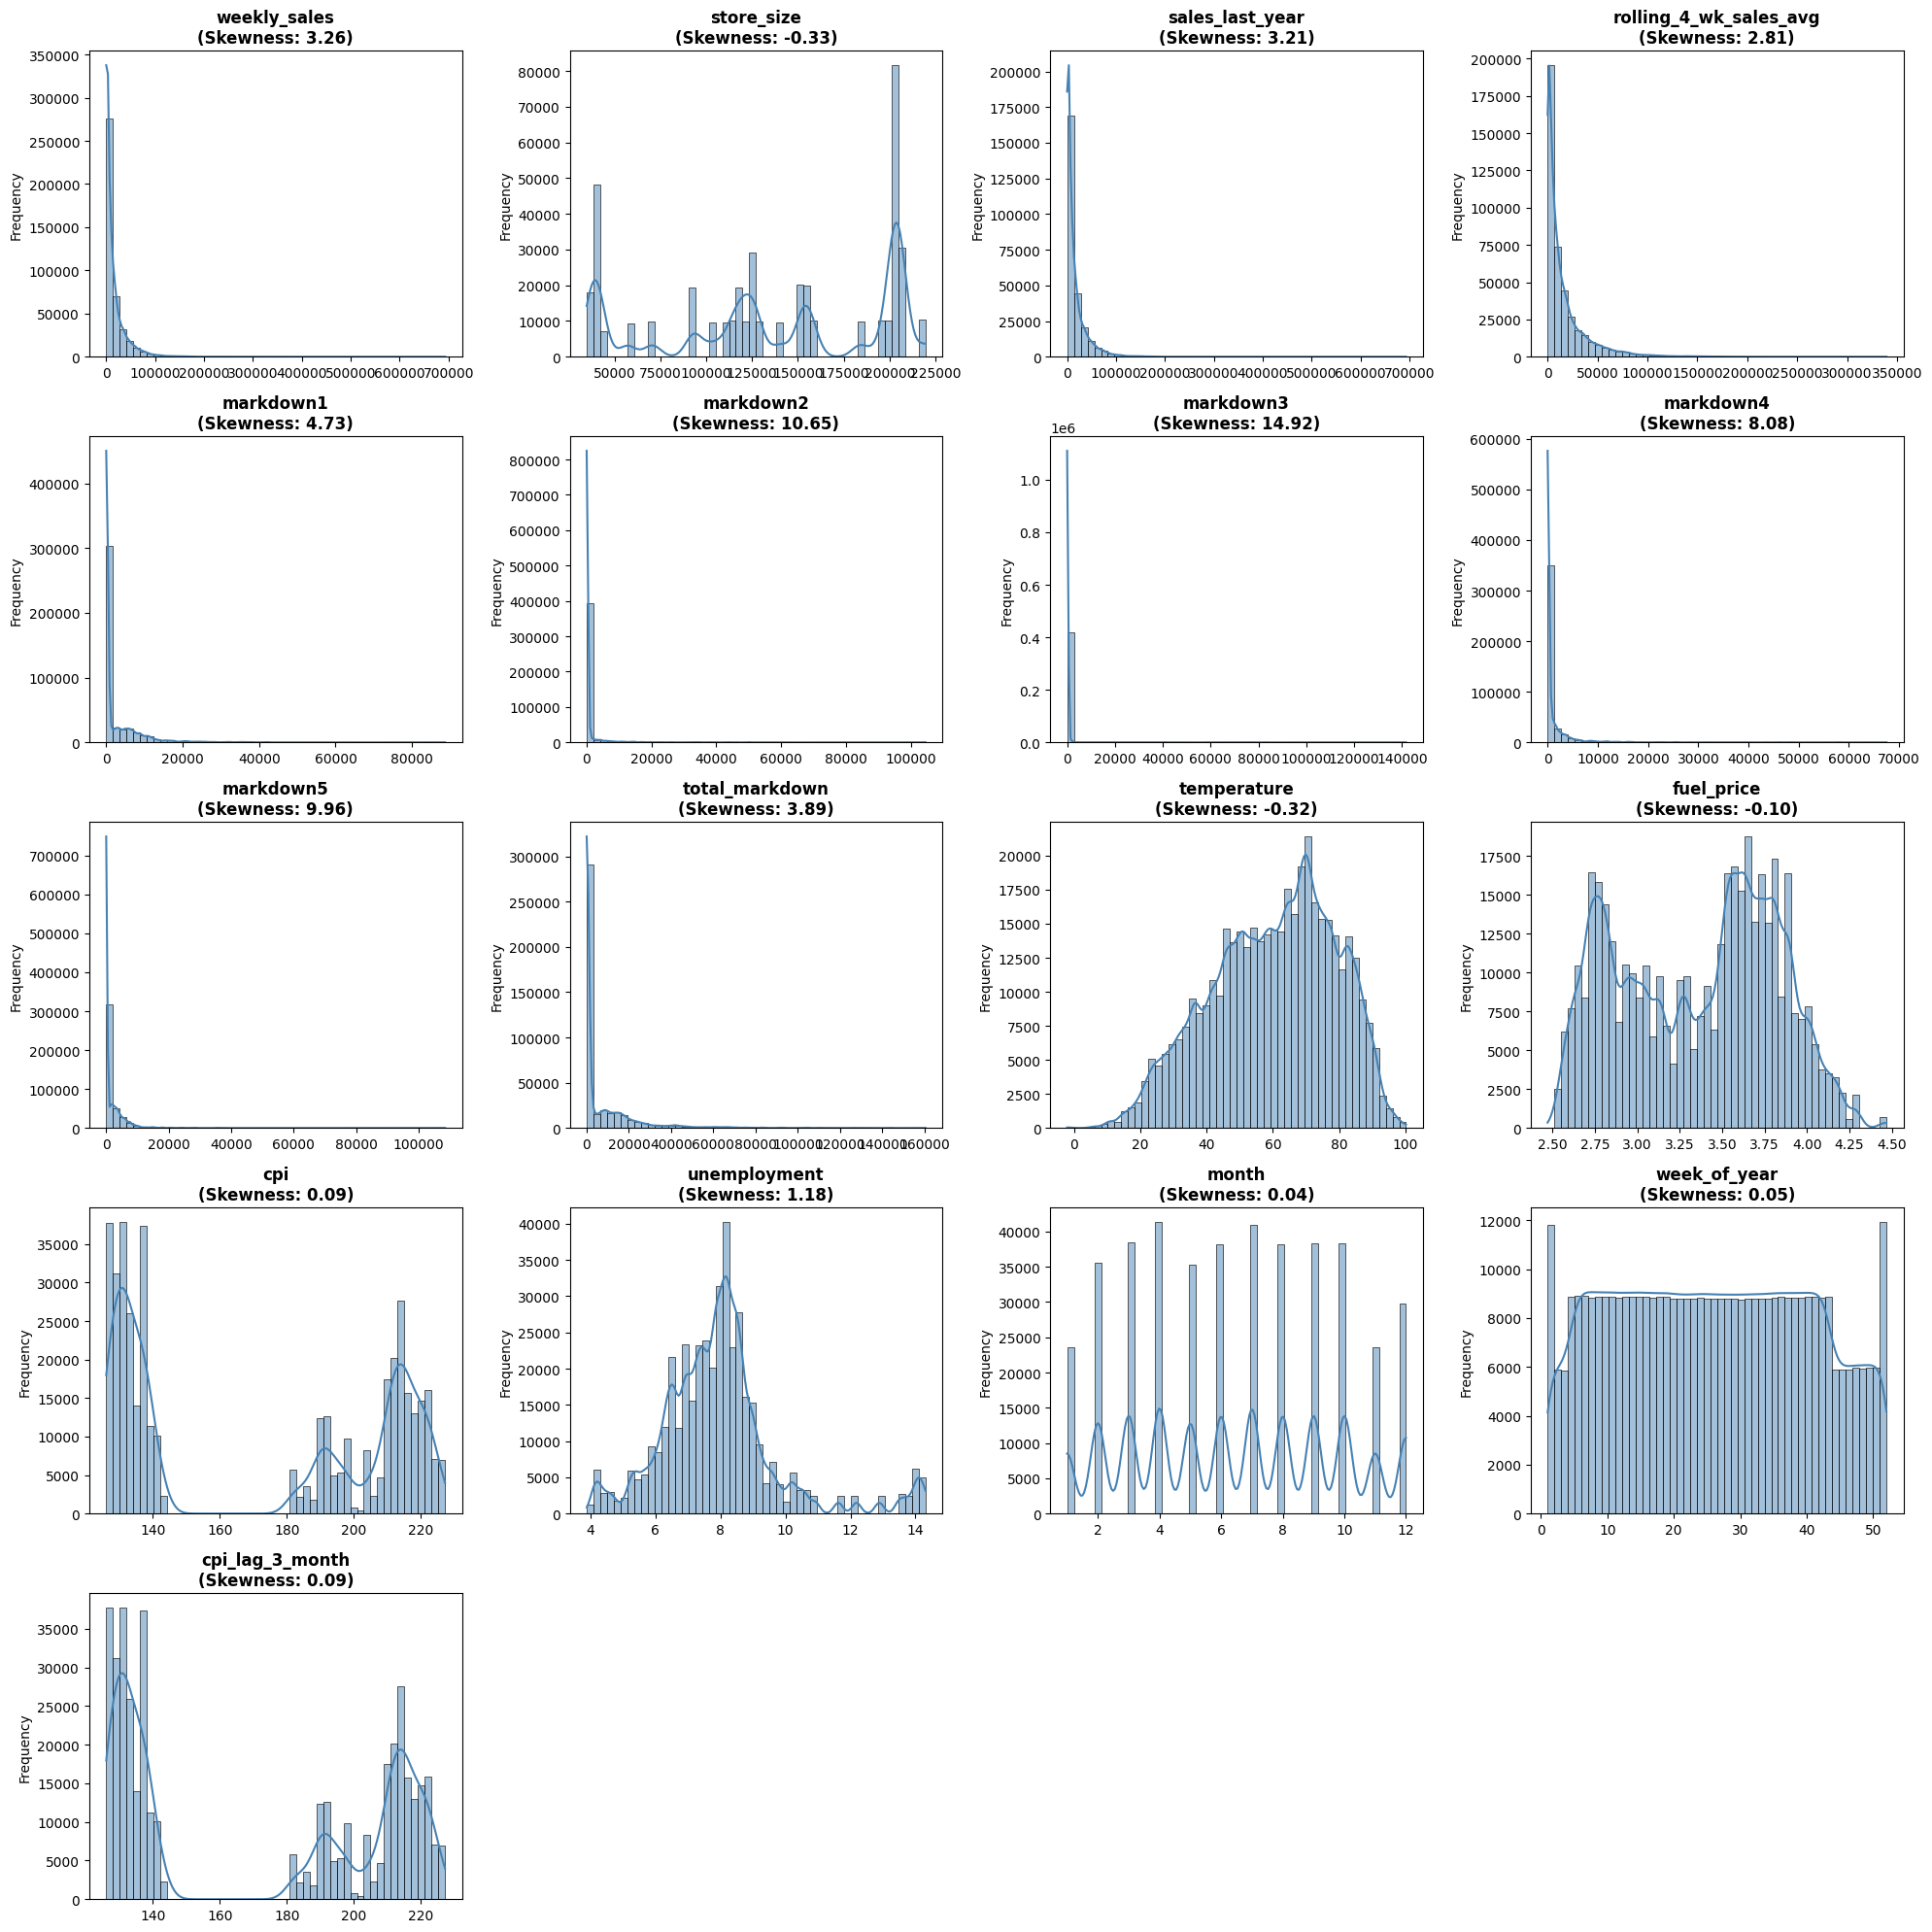

In [ ]:
import math

numerical_cols = [
    'weekly_sales', 'store_size', 'sales_last_year', 'rolling_4_wk_sales_avg', 
    'markdown1','markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
    'temperature', 'fuel_price', 'cpi', 'unemployment', 'month', 'week_of_year', 'cpi_lag_3_month'
]

# 1. Define grid dimensions dynamically (e.g., 4 plots per row)
num_plots = len(numerical_cols)
cols = 4
rows = math.ceil(num_plots / cols)

# 2. Create the grid layout
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten() # Flattens the 2D axes array into a 1D list for easy looping

# 3. Loop through columns and plot
for i, col in enumerate(numerical_cols):
    # Calculate skewness safely, dropping NaNs just for the calculation
    skew_val = df[col].dropna().skew() 
    
    # Plot histogram and KDE
    sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[i], color='steelblue')
    
    # Add context to the plot
    axes[i].set_title(f'{col}\n(Skewness: {skew_val:.2f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# 4. Clean up any empty/unused subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so titles and axes don't overlap
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'store_type',
       'store_size', 'temperature', 'fuel_price', 'cpi', 'unemployment',
       'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5',
       'total_markdown', 'month', 'week_of_year', 'rolling_4_wk_sales_avg',
       'sales_last_year', 'cpi_lag_3_month'],
      dtype='object')

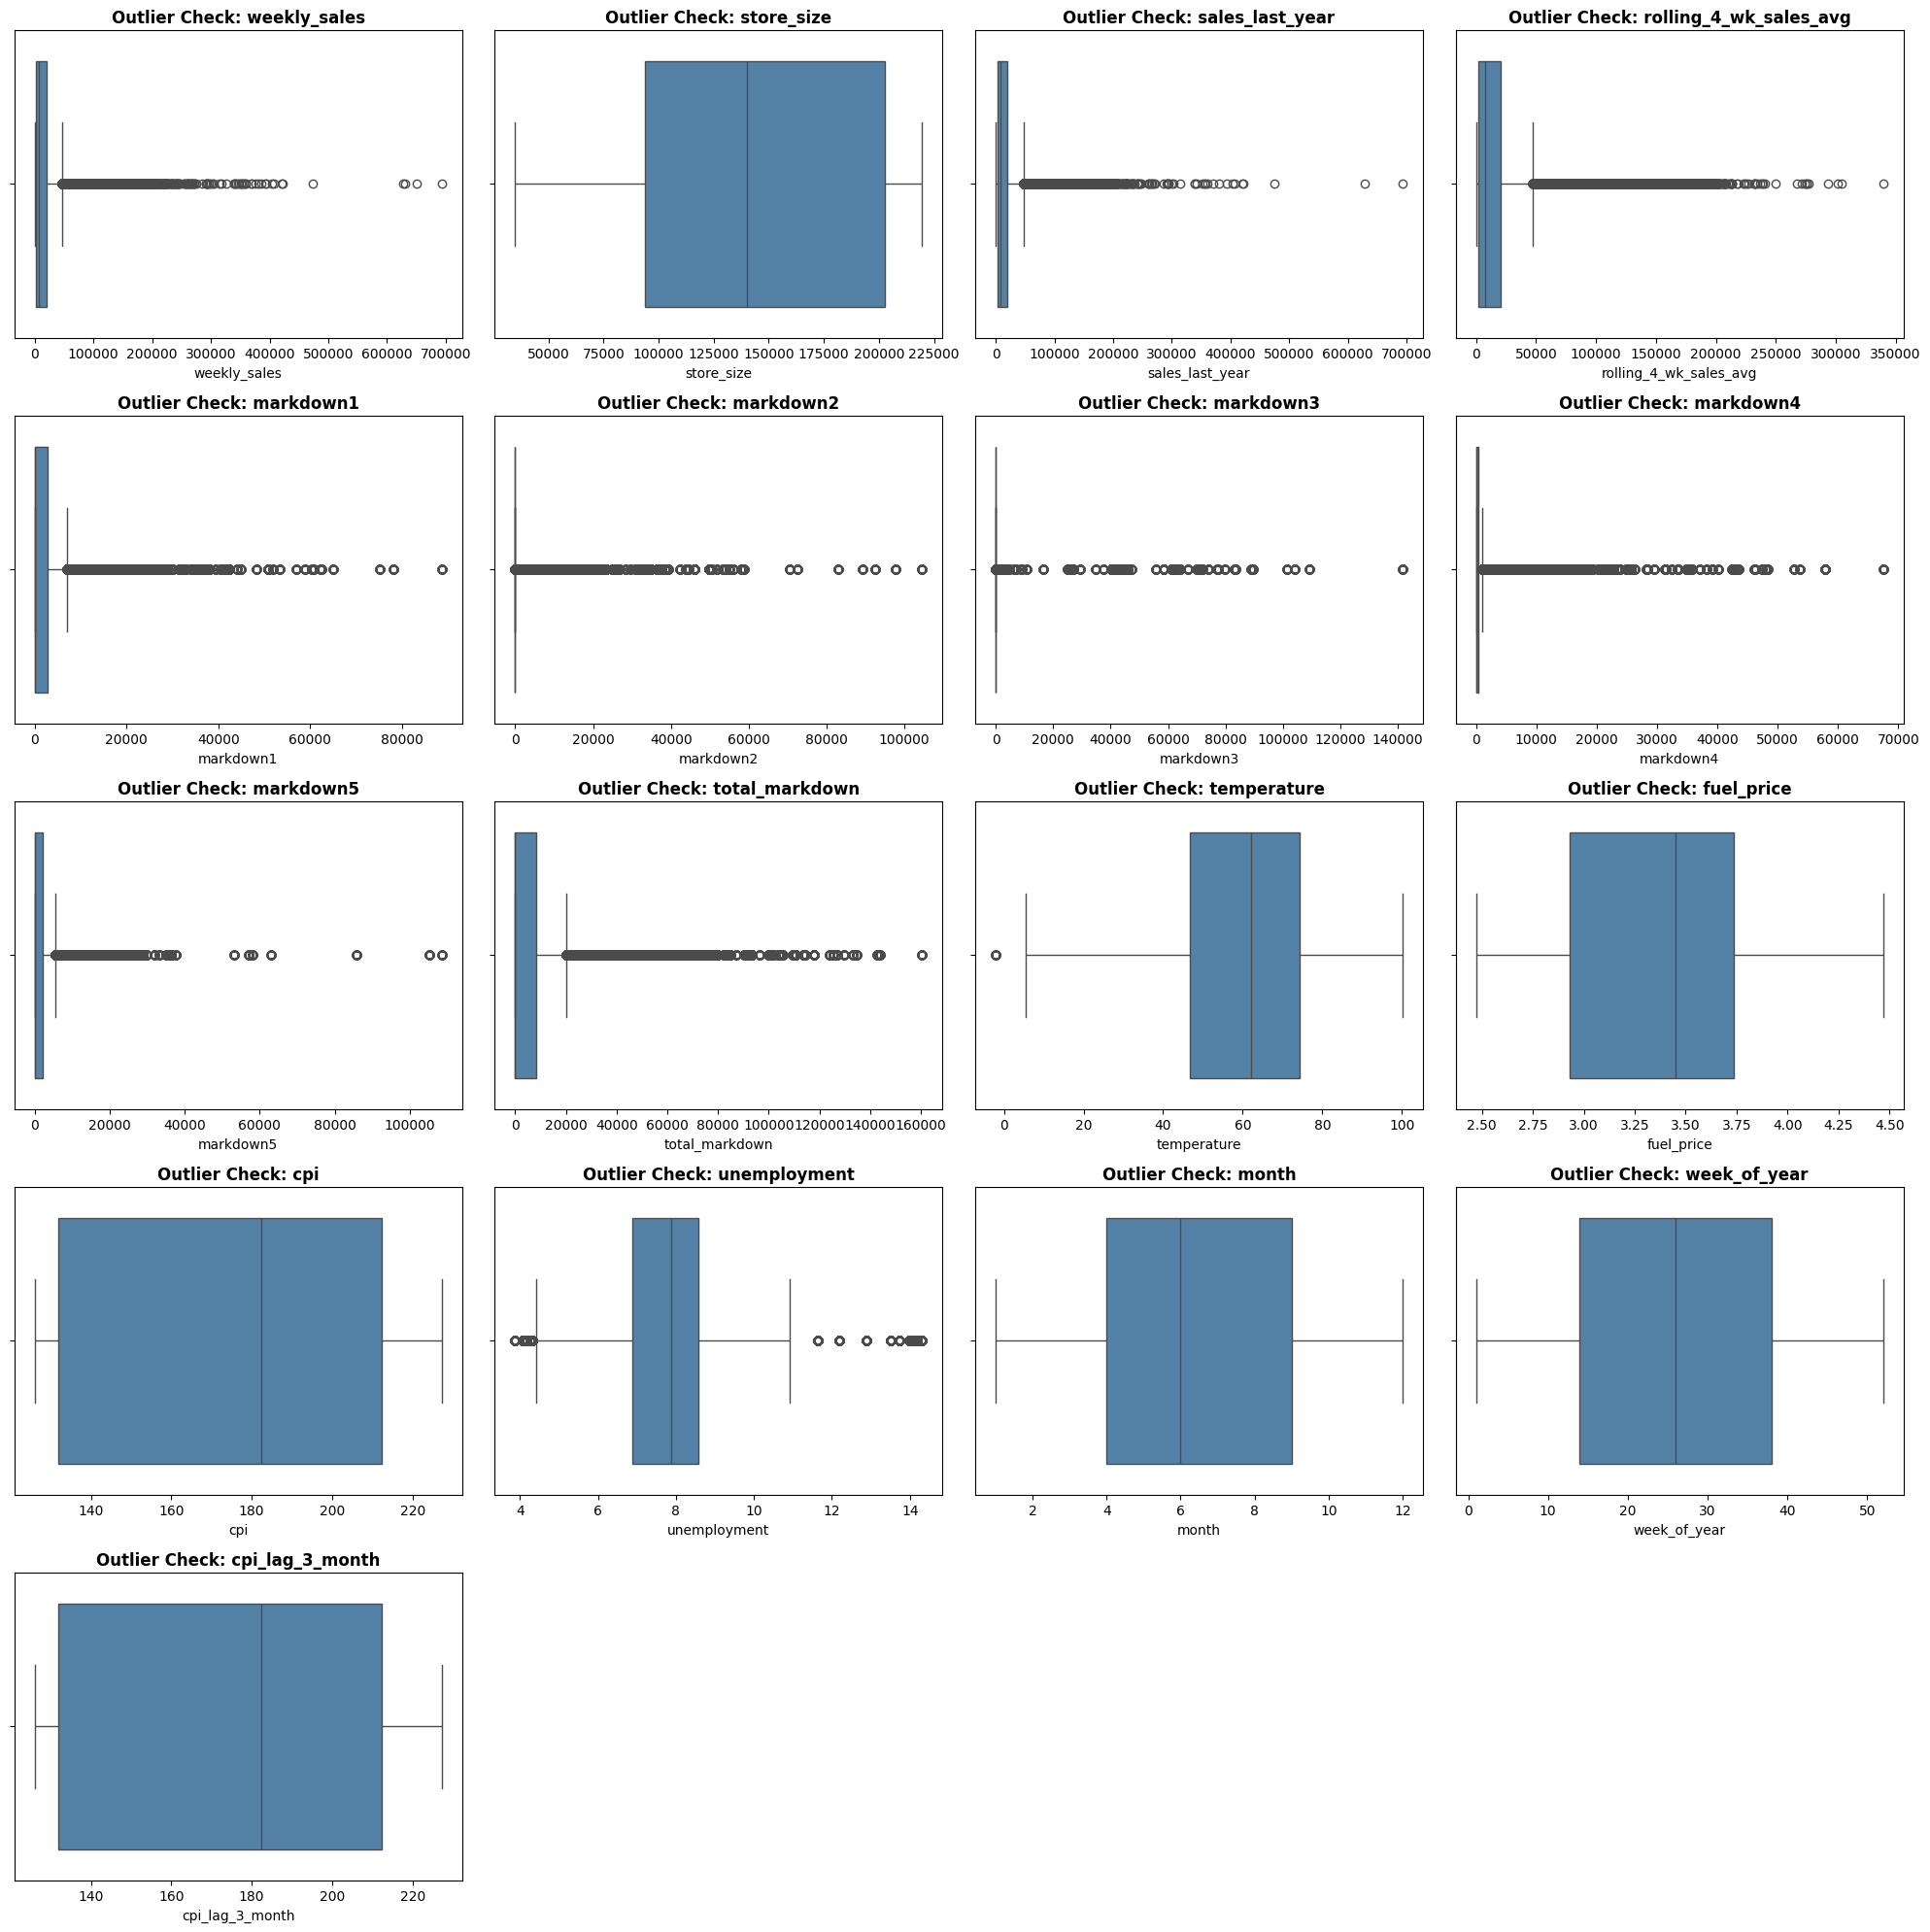

In [ ]:

numerical_cols = [
    'weekly_sales', 'store_size', 'sales_last_year', 'rolling_4_wk_sales_avg', 
    'markdown1','markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
    'temperature', 'fuel_price', 'cpi', 'unemployment', 'month', 'week_of_year', 'cpi_lag_3_month'
]

# 1. Define grid dimensions dynamically
num_plots = len(numerical_cols)
cols = 4
rows = math.ceil(num_plots / cols)

# 2. Create the grid layout
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten() 

# 3. Loop through columns and plot
for i, col in enumerate(numerical_cols):

    # Plot horizontal boxplot
    sns.boxplot(data=df, x=col, ax=axes[i], color='steelblue')
    
    # Add context to the plot
    axes[i].set_title(f"Outlier Check: {col}", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('') # Removed 'Frequency' because it doesn't apply to boxplots

# 4. Clean up any empty/unused subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()
plt.show()

### 2. Feature Collinearity Heatmap
Check if our lagged features or continuous variables (CPI, Unemployment) are perfectly correlated, which could cause multicollinearity issues for linear models.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   store                   421570 non-null  int32  
 1   dept                    421570 non-null  int32  
 2   date                    421570 non-null  object 
 3   weekly_sales            421570 non-null  float64
 4   isholiday               421570 non-null  bool   
 5   store_type              421570 non-null  object 
 6   store_size              421570 non-null  int32  
 7   temperature             421570 non-null  float64
 8   fuel_price              421570 non-null  float64
 9   cpi                     421570 non-null  float32
 10  unemployment            421570 non-null  float32
 11  markdown1               421570 non-null  float32
 12  markdown2               421570 non-null  float32
 13  markdown3               421570 non-null  float32
 14  markdown4           

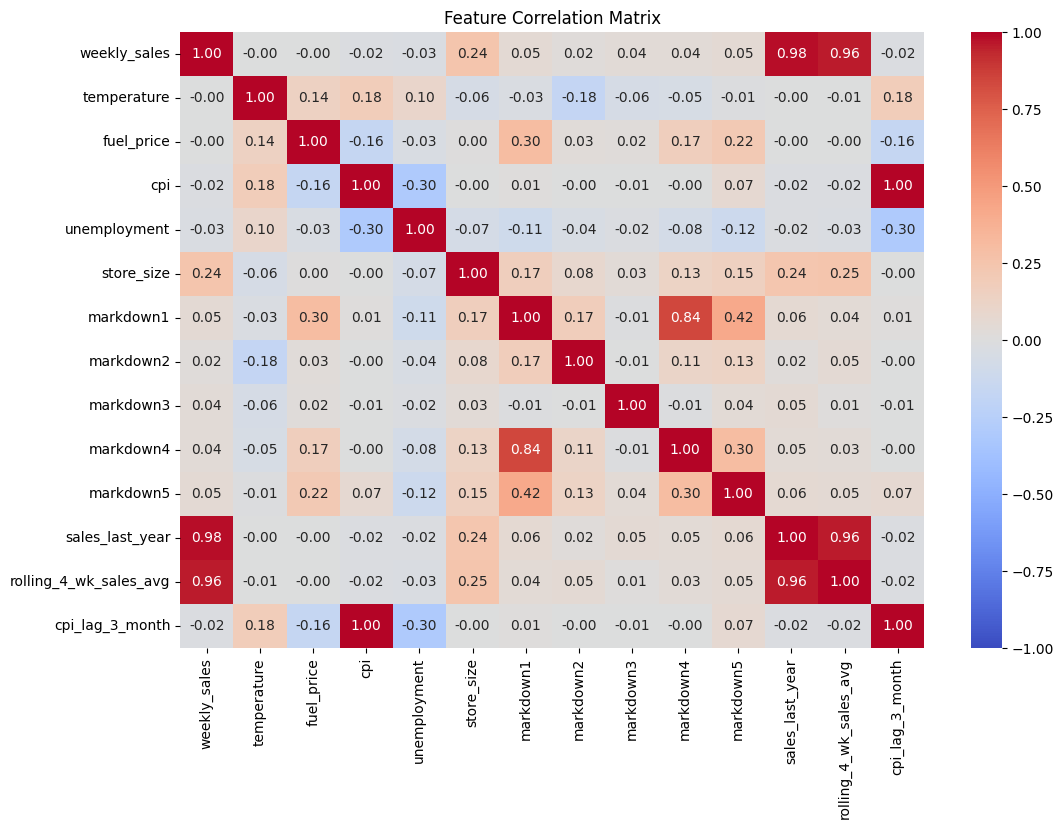

In [ ]:
continuous_cols = ['weekly_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment',
 'store_size', 'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5', 'sales_last_year', 'rolling_4_wk_sales_avg', 'cpi_lag_3_month']

# Need to drop NaNs temporarily for accurate correlation calculations
corr = df[continuous_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

### 3. Categorical Cardinality
Evaluate the uniqueness of Store, Dept, and Type to determine if One-Hot Encoding is feasible.

In [ ]:
df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'store_type',
       'store_size', 'temperature', 'fuel_price', 'cpi', 'unemployment',
       'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5',
       'total_markdown', 'month', 'week_of_year', 'rolling_4_wk_sales_avg',
       'sales_last_year', 'cpi_lag_3_month'],
      dtype='object')

In [ ]:
print("Unique Stores:", df['store'].nunique())
print("Unique Departments:", df['dept'].nunique())
print("Unique Types:", df['store_type'].nunique())
print("Total resulting OHE columns if combined:", df['store'].nunique() + df['dept'].nunique() + df['store_type'].nunique())

Unique Stores: 45
Unique Departments: 81
Unique Types: 3
Total resulting OHE columns if combined: 129
